In [1]:
import pdfplumber
import sklearn
import numpy as np
import pandas as pd

In [2]:
#opening the pdf file
data = pdfplumber.open(r"C:\Users\User\Downloads\data.pdf")

In [3]:
pages=data.pages

In [4]:
chains=[] #list of chains
Atom_E=[] #list for atomization energy
form_E=[] #list for formation energy
c=[] #list for lattice parameters
k=[] #list for spring constant
E_A=[] #list for Electron affinity
B_G=[] #list for band gap
eps_c_e=[] #list for electronic dielectric constant
eps_c_tot=[] #list for total dielectric constant
#extracting tables from each page and appending values
for page in pages:
    chains.extend(page.extract_tables()[0][1][1].split("\n2 2 2 2\n"))
    Atom_E.extend(page.extract_tables()[0][1][2].split("\n"))
    form_E.extend(page.extract_tables()[0][1][3].split("\n"))
    c.extend(page.extract_tables()[0][1][4].split("\n"))
    k.extend(page.extract_tables()[0][1][5].split("\n"))
    E_A.extend(page.extract_tables()[0][1][6].split("\n"))
    B_G.extend(page.extract_tables()[0][1][7].split("\n"))
    eps_c_e.extend(page.extract_tables()[0][1][8].split("\n"))
    eps_c_tot.extend(page.extract_tables()[0][1][9].split("\n"))
chains=[i.split() for i in chains] #splitting each string into lists of substrings

In [98]:

mapping = {
    "CH":   0,
    "SiF":  1,
    "SiCl": 2,
    "GeF":  3,
    "GeCl": 4,
    "SnF":  5,
    "SnCl": 6 
}
num_chains = len(chains)
vectors = np.zeros((num_chains, 20))

for j, chain in enumerate(chains):
    L = 1
    for i in range(1, 5):
        if i < 4 and chain[i] == chain[i-1]:
            L += 1
        else:
            item = chain[i-1]
            idx = mapping.get(item)
            
            if idx is not None:
                if idx < 6:
                    vectors[j][idx] += L
                if L >= 2:
                    vectors[j][idx + 6] += (L - 1)
                if L >= 3:
                    vectors[j][idx + 13] += (L - 2)
            
            L = 1

vectors=vectors/4

In [5]:
#convert string arrays into float
Atom_E=np.array(Atom_E, dtype=np.float64)
form_E=np.array(form_E, dtype=np.float64)
c=np.array(c, dtype=np.float64)
k=np.array(k, dtype=np.float64)
E_A=np.array(E_A, dtype=np.float64)
B_G=np.array(B_G, dtype=np.float64)
eps_c_e=np.array(eps_c_e, dtype=np.float64)
eps_c_tot=np.array(eps_c_tot, dtype=np.float64)


In [100]:
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [101]:
#splitting array into test and train datasets
X_train_Atom_E, X_test_Atom_E, y_train_Atom_E, y_test_Atom_E = train_test_split(vectors, Atom_E, test_size=(45/175), random_state=42)

In [6]:
#creating grid for grid search
param_grid_Atom_E = {
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),     
    'kernel': ['rbf']
}

In [103]:
#model definition
krr_Atom_E = KernelRidge()

In [104]:
#grid search
grid_search_Atom_E = GridSearchCV(estimator=krr_Atom_E, param_grid=param_grid_Atom_E, cv=5, n_jobs=-1)

In [105]:
#fitting the model
grid_search_Atom_E.fit(X_train_Atom_E, y_train_Atom_E)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1e-06)


In [106]:
print("Best Hyperparameters: ", grid_search_Atom_E.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_Atom_E.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(1e-06), 'gamma': np.float64(0.001), 'kernel': 'rbf'}
Best Accuracy Score: 99.04%


In [107]:
best_krr_Atom_E = grid_search_Atom_E.best_estimator_
test_accuracy_Atom_E = best_krr_Atom_E.score(X_test_Atom_E, y_test_Atom_E)
print("Test Accuracy: {:.2f}%".format(test_accuracy_Atom_E * 100))

Test Accuracy: 99.02%


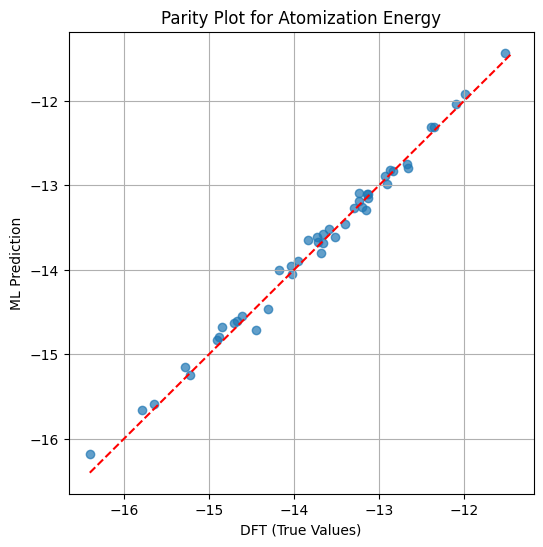

Pearson r: 0.9956102461544988


In [233]:


# Predictions
y_pred_Atom_E = best_krr_Atom_E.predict(X_test_Atom_E)

plt.figure(figsize=(6,6))

plt.scatter(y_test_Atom_E, y_pred_Atom_E, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_Atom_E.min(), y_pred_Atom_E.min())
max_val = max(y_test_Atom_E.max(), y_pred_Atom_E.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for Atomization Energy")

plt.grid(True)
plt.show()

r = np.corrcoef(y_test_Atom_E, y_pred_Atom_E)[0, 1]

print("Pearson r:", r)

In [109]:
#splitting into test and train datasets
X_train_form_E, X_test_form_E, y_train_form_E, y_test_form_E = train_test_split(vectors, form_E, test_size=(45/175), random_state=40)

In [110]:
#grid for grid search
param_grid_form_E ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [111]:
#model defintion
krr_form_E = KernelRidge()

In [112]:
#grid search
grid_search_form_E = GridSearchCV(estimator=krr_form_E, param_grid=param_grid_form_E, cv=5, n_jobs=-1)

In [113]:
#fitting the model
grid_search_form_E.fit(X_train_form_E, y_train_form_E)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.0001)


In [114]:
print("Best Hyperparameters: ", grid_search_form_E.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_form_E.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(0.0001), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 99.01%


In [115]:
best_krr_form_E = grid_search_form_E.best_estimator_
test_accuracy_form_E = best_krr_form_E.score(X_test_form_E, y_test_form_E)
print("Test Accuracy: {:.2f}%".format(test_accuracy_form_E * 100))

Test Accuracy: 98.85%


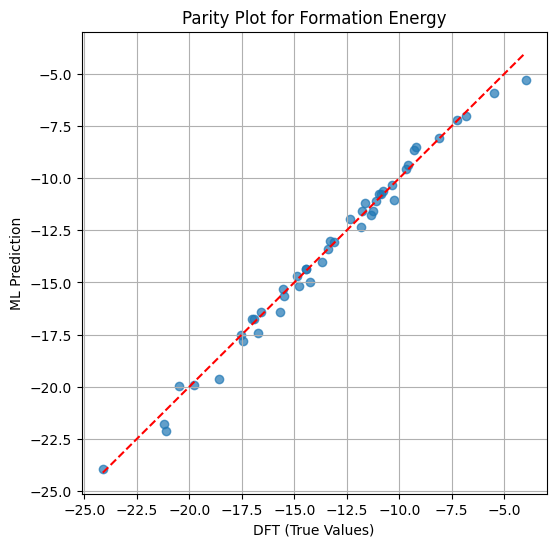

Pearson r: 0.9946530869792671


In [236]:

y_pred = best_krr_form_E.predict(X_test_form_E)

plt.figure(figsize=(6,6))

plt.scatter(y_test_form_E, y_pred, alpha=0.7)

# Diagonal line
min_val = min(y_test_form_E.min(), y_pred.min())
max_val = max(y_test_form_E.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for Formation Energy")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_form_E, y_pred)[0, 1]

print("Pearson r:", r)

In [117]:
#splitting into test and train sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(vectors, c, test_size=(45/175), random_state=0)

In [118]:
#grid for grid search
param_grid_c ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [119]:
#model definition
krr_c = KernelRidge()

In [120]:
#grid search
grid_search_c = GridSearchCV(estimator=krr_c, param_grid=param_grid_c, cv=5, n_jobs=-1)

In [121]:
#fit model 
grid_search_c.fit(X_train_c, y_train_c)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1e-06)


In [122]:
print("Best Hyperparameters: ", grid_search_c.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_c.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(1e-06), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 94.56%


In [123]:
best_krr_c = grid_search_c.best_estimator_
test_accuracy_c = best_krr_c.score(X_test_c, y_test_c)
print("Test Accuracy: {:.2f}%".format(test_accuracy_c * 100))

Test Accuracy: 90.57%


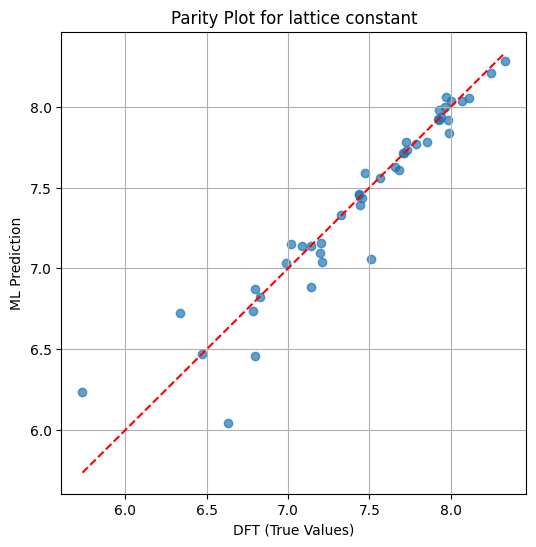

Pearson r: 0.9533724790918666


In [237]:
# Predictions
y_pred_c = best_krr_c.predict(X_test_c)

plt.figure(figsize=(6,6))

plt.scatter(y_test_c, y_pred_c, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_c.min(), y_pred_c.min())
max_val = max(y_test_c.max(), y_pred_c.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for lattice constant")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_c, y_pred_c)[0, 1]

print("Pearson r:", r)

In [176]:
#splitting into test and train sets
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(vectors, k, test_size=(45/175))

In [177]:
#grid for grid search
param_grid_k ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [178]:
#model definiton
krr_k = KernelRidge()

In [179]:
#grid search 
grid_search_k = GridSearchCV(estimator=krr_k, param_grid=param_grid_k, cv=5, n_jobs=-1)

In [180]:
#model fitting
grid_search_k.fit(X_train_k, y_train_k)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1e-06)


In [181]:
print("Best Hyperparameters: ", grid_search_k.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_k.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(1e-06), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 81.79%


In [182]:
best_krr_k = grid_search_k.best_estimator_
test_accuracy_k = best_krr_k.score(X_test_k, y_test_k)
print("Test Accuracy: {:.2f}%".format(test_accuracy_k * 100))

Test Accuracy: 83.94%


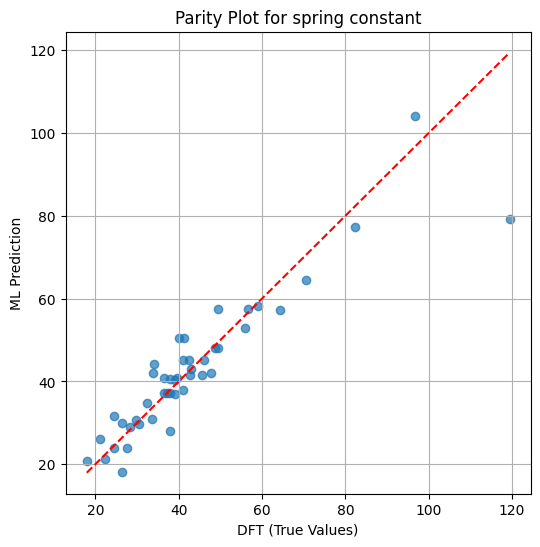

Pearson r: 0.9190620506762113


In [238]:
# Predictions
y_pred_k = best_krr_k.predict(X_test_k)

plt.figure(figsize=(6,6))

plt.scatter(y_test_k, y_pred_k, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_k.min(), y_pred_k.min())
max_val = max(y_test_k.max(), y_pred_k.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for spring constant")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_k, y_pred_k)[0, 1]

print("Pearson r:", r)

In [184]:
#splitting into test and train sets
X_train_E_A, X_test_E_A, y_train_E_A, y_test_E_A = train_test_split(vectors, E_A, test_size=(45/175))

In [185]:
#grid for grid search
param_grid_E_A ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [186]:
#model definition
krr_E_A = KernelRidge()

In [187]:
#grid search
grid_search_E_A = GridSearchCV(estimator=krr_E_A, param_grid=param_grid_E_A, cv=5, n_jobs=-1)

In [188]:
#fitting the model
grid_search_E_A.fit(X_train_E_A, y_train_E_A)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1e-05)


In [189]:
print("Best Hyperparameters: ", grid_search_E_A.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_E_A.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(1e-05), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 88.62%


In [190]:
best_krr_E_A = grid_search_E_A.best_estimator_
test_accuracy_E_A = best_krr_E_A.score(X_test_E_A, y_test_E_A)
print("Test Accuracy: {:.2f}%".format(test_accuracy_E_A * 100))

Test Accuracy: 81.45%


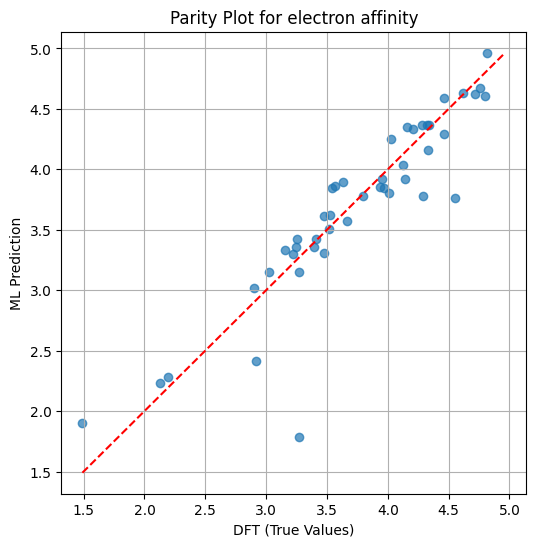

Pearson r: 0.9096194476890929


In [239]:

y_pred_E_A = best_krr_E_A.predict(X_test_E_A)

plt.figure(figsize=(6,6))

plt.scatter(y_test_E_A, y_pred_E_A, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_E_A.min(), y_pred_E_A.min())
max_val = max(y_test_E_A.max(), y_pred_E_A.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for electron affinity")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_E_A, y_pred_E_A)[0, 1]

print("Pearson r:", r)

In [240]:
#split into training and test sets
X_train_B_G, X_test_B_G, y_train_B_G, y_test_B_G = train_test_split(vectors, B_G, test_size=(45/175))

In [241]:
#grid for grid search
param_grid_B_G ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [242]:
#model definiton
krr_B_G = KernelRidge()

In [243]:
#grid search
grid_search_B_G = GridSearchCV(estimator=krr_B_G, param_grid=param_grid_B_G, cv=5, n_jobs=-1)

In [196]:
#model fitting
grid_search_B_G.fit(X_train_B_G, y_train_B_G)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.001)


In [197]:
print("Best Hyperparameters: ", grid_search_B_G.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_B_G.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(0.001), 'gamma': np.float64(0.1), 'kernel': 'rbf'}
Best Accuracy Score: 86.68%


In [198]:
best_krr_B_G = grid_search_B_G.best_estimator_
test_accuracy_B_G = best_krr_B_G.score(X_test_B_G, y_test_B_G)
print("Test Accuracy: {:.2f}%".format(test_accuracy_B_G * 100))

Test Accuracy: 80.67%


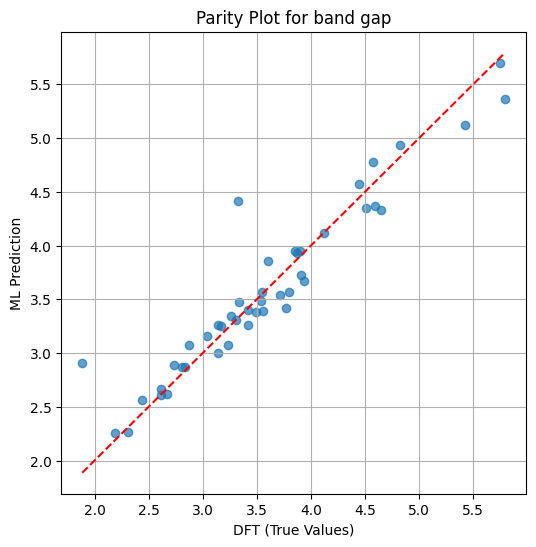

Pearson r: 0.9501089110488866


In [244]:

# Predictions
y_pred_B_G = best_krr_B_G.predict(X_test_B_G)

plt.figure(figsize=(6,6))

plt.scatter(y_test_B_G, y_pred_B_G, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_B_G.min(), y_pred_B_G.min())
max_val = max(y_test_B_G.max(), y_pred_B_G.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for band gap")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_B_G, y_pred_B_G)[0, 1]

print("Pearson r:", r)

In [216]:
#splitting into training and testing sets
X_train_eps_c_e, X_test_eps_c_e, y_train_eps_c_e, y_test_eps_c_e = train_test_split(vectors, eps_c_e, test_size=(45/175))

In [217]:
#grid for grid search
param_grid_eps_c_e ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [218]:
#model definiton
krr_eps_c_e = KernelRidge()

In [219]:
#grid search
grid_search_eps_c_e = GridSearchCV(estimator=krr_eps_c_e, param_grid=param_grid_eps_c_e, cv=5, n_jobs=-1)

In [220]:
#fitting the model
grid_search_eps_c_e.fit(X_train_eps_c_e, y_train_eps_c_e)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.0001)


In [221]:
print("Best Hyperparameters: ", grid_search_eps_c_e.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_eps_c_e.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(0.0001), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 84.54%


In [222]:
best_krr_eps_c_e = grid_search_eps_c_e.best_estimator_
test_accuracy_eps_c_e = best_krr_eps_c_e.score(X_test_eps_c_e, y_test_eps_c_e)
print("Test Accuracy: {:.2f}%".format(test_accuracy_eps_c_e * 100))

Test Accuracy: 85.85%


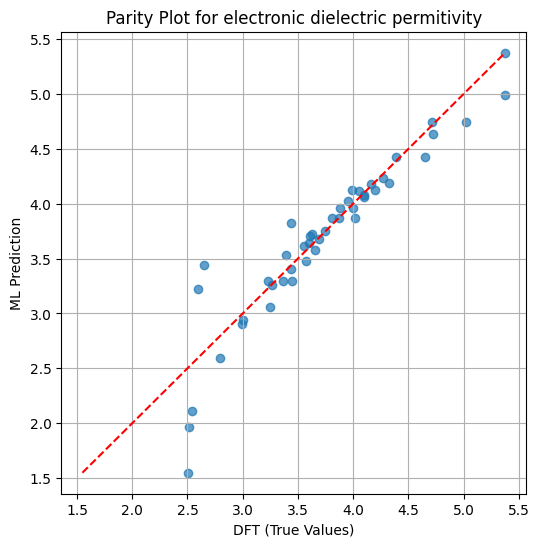

Pearson r: 0.9356851963683025


In [245]:


# Predictions
y_pred_eps_c_e = best_krr_eps_c_e.predict(X_test_eps_c_e)

plt.figure(figsize=(6,6))

plt.scatter(y_test_eps_c_e, y_pred_eps_c_e, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_eps_c_e.min(), y_pred_eps_c_e.min())
max_val = max(y_test_eps_c_e.max(), y_pred_eps_c_e.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for electronic dielectric permitivity")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_eps_c_e, y_pred_eps_c_e)[0, 1]

print("Pearson r:", r)

In [224]:
#splitting into training and testing sets
X_train_eps_c_tot, X_test_eps_c_tot, y_train_eps_c_tot, y_test_eps_c_tot = train_test_split(vectors, eps_c_tot, test_size=(45/175))

In [225]:
#grid for grid search
param_grid_eps_c_tot ={
    'alpha': np.logspace(-6, 2, 9),
    'gamma': np.logspace(-6, 2, 9),
    'kernel': ['rbf']
}

In [226]:
#model definition
krr_eps_c_tot = KernelRidge()

In [227]:
#grid search
grid_search_eps_c_tot = GridSearchCV(estimator=krr_eps_c_tot, param_grid=param_grid_eps_c_tot, cv=5, n_jobs=-1)

In [228]:
#fitting the model
grid_search_eps_c_tot.fit(X_train_eps_c_tot, y_train_eps_c_tot)

,estimator,KernelRidge()
,param_grid,"{'alpha': array([1.e-06... 1.e+02]), 'gamma': array([1.e-06... 1.e+02]), 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1e-06)


In [229]:
print("Best Hyperparameters: ", grid_search_eps_c_tot.best_params_)
print("Best Accuracy Score: {:.2f}%".format(grid_search_eps_c_tot.best_score_ * 100))

Best Hyperparameters:  {'alpha': np.float64(1e-06), 'gamma': np.float64(0.01), 'kernel': 'rbf'}
Best Accuracy Score: 85.94%


In [230]:
best_krr_eps_c_tot = grid_search_eps_c_tot.best_estimator_
test_accuracy_eps_c_tot = best_krr_eps_c_tot.score(X_test_eps_c_tot, y_test_eps_c_tot)
print("Test Accuracy: {:.2f}%".format(test_accuracy_eps_c_tot * 100))

Test Accuracy: 86.10%


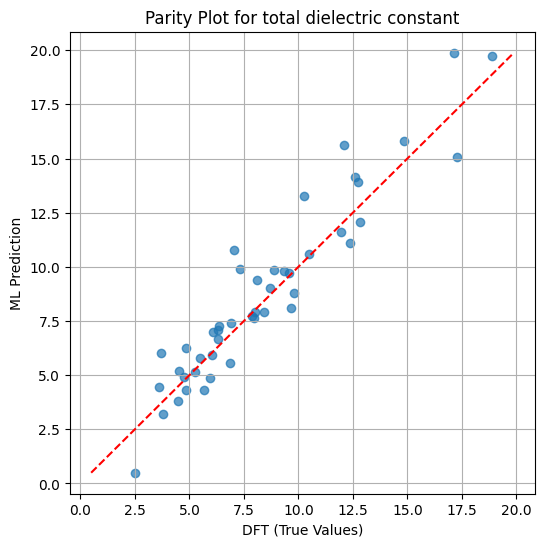

Pearson r: 0.945765670319672


In [246]:
# Predictions
y_pred_eps_c_tot = best_krr_eps_c_tot.predict(X_test_eps_c_tot)

plt.figure(figsize=(6,6))

plt.scatter(y_test_eps_c_tot, y_pred_eps_c_tot, alpha=0.7)

# Diagonal line (perfect prediction)
min_val = min(y_test_eps_c_tot.min(), y_pred_eps_c_tot.min())
max_val = max(y_test_eps_c_tot.max(), y_pred_eps_c_tot.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("DFT (True Values)")
plt.ylabel("ML Prediction")
plt.title("Parity Plot for total dielectric constant")

plt.grid(True)
plt.show()
r = np.corrcoef(y_test_eps_c_tot, y_pred_eps_c_tot)[0, 1]

print("Pearson r:", r)